In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import os

DATA_DIR = '../data'
RESULTS_DIR = '../results'

# Load the partial correlations from tel_rdna_correlation
partial_df = pd.read_csv(os.path.join(RESULTS_DIR, 'partial_correlations.csv'))

print("Partial correlations loaded:")
print(partial_df.shape)
print(partial_df.columns.tolist())

Partial correlations loaded:
(49, 15)
['tissue', 'n', 'r_rDNA_P53', 'p_rDNA_P53', 'r_Telo_P53', 'p_Telo_P53', 'r_OxPhos_P53', 'p_OxPhos_P53', 'r_DNA_P53', 'p_DNA_P53', 'r_ROS_P53', 'p_ROS_P53', 'r_rDNA_age', 'r_Telo_age', 'r_P53_age']


In [6]:
# Load the residualized scores dataframe
df_resid = pd.read_csv(os.path.join(RESULTS_DIR, 'df_resid_scores.csv'))

print(f"Loaded: {df_resid.shape}")
print(f"Tissues: {df_resid['SMTSD'].nunique()}")
print(f"Samples: {len(df_resid)}")
print()
print("Score columns available:")
score_cols = [c for c in df_resid.columns if 'score' in c.lower()]
for c in score_cols:
    print(f"  {c}")

Loaded: (17382, 24)
Tissues: 54
Samples: 17382

Score columns available:
  rDNA_score
  Telo_score
  P53_score
  OxPhos_score
  DNA_repair_score
  ROS_score
  rDNA_score_resid
  Telo_score_resid
  P53_score_resid
  OxPhos_score_resid
  DNA_repair_score_resid
  ROS_score_resid
  rDNA_score_resid_pc1resid
  Telo_score_resid_pc1resid
  P53_score_resid_pc1resid
  OxPhos_score_resid_pc1resid
  DNA_repair_score_resid_pc1resid
  ROS_score_resid_pc1resid


In [7]:
mediation_results = []

for tissue in sorted(df_resid['SMTSD'].unique()):
    tdf = df_resid[df_resid['SMTSD'] == tissue].copy()
    n = len(tdf)
    if n < 50:
        continue

    for predictor, pred_label in [
        ('Telo_score_resid_pc1resid', 'Telo'),
        ('rDNA_score_resid_pc1resid', 'rDNA'),
    ]:
        try:
            med = pg.mediation_analysis(
                data=tdf,
                x=predictor,
                m='OxPhos_score_resid_pc1resid',
                y='P53_score_resid_pc1resid',
                seed=42,
                n_boot=5000,
            )

            direct   = med[med['path'] == 'Direct']['coef'].values[0]
            indirect = med[med['path'] == 'Indirect']['coef'].values[0]
            total    = med[med['path'] == 'Total']['coef'].values[0]
            ind_lo   = med[med['path'] == 'Indirect']['CI2.5'].values[0]
            ind_hi   = med[med['path'] == 'Indirect']['CI97.5'].values[0]

            sig_mediation = (ind_lo > 0 and ind_hi > 0) or \
                            (ind_lo < 0 and ind_hi < 0)
            prop_mediated = indirect / total if abs(total) > 0.001 else np.nan

            mediation_results.append({
                'tissue':        tissue,
                'predictor':     pred_label,
                'n':             n,
                'direct':        direct,
                'indirect':      indirect,
                'total':         total,
                'ind_CI_lo':     ind_lo,
                'ind_CI_hi':     ind_hi,
                'sig_mediation': sig_mediation,
                'prop_mediated': prop_mediated,
            })

        except Exception as e:
            print(f"  Skipped {tissue} / {pred_label}: {e}")

med_df = pd.DataFrame(mediation_results)
med_df.to_csv(os.path.join(RESULTS_DIR, 'mediation_results.csv'), index=False)

print(f"Ran mediation analysis for {len(med_df)} tissue/predictor combinations")
print()

for pred in ['Telo', 'rDNA']:
    sub = med_df[med_df['predictor'] == pred]
    sig = sub[sub['sig_mediation']]
    pos = sig[sig['indirect'] > 0]
    neg = sig[sig['indirect'] < 0]
    print(f"{pred} -> OxPhos -> P53: significant in {len(sig)}/{len(sub)} tissues")
    print(f"  Positive indirect (suppression): {len(pos)}")
    print(f"  Negative indirect (mediation):   {len(neg)}")
    print()

Task was destroyed but it is pending!
task: <Task pending name='Task-85' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\eddie\mambaforge\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-86' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\eddie\mambaforge\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\eddie\mambaforge\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\eddie\mambaforge\lib\tokenize.py:527: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-86' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\eddie\mambaforge\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]>


Ran mediation analysis for 98 tissue/predictor combinations

Telo -> OxPhos -> P53: significant in 37/49 tissues
  Positive indirect (suppression): 35
  Negative indirect (mediation):   2

rDNA -> OxPhos -> P53: significant in 41/49 tissues
  Positive indirect (suppression): 40
  Negative indirect (mediation):   1



In [8]:
print(len(med_df))
print(med_df.head())

98
                         tissue predictor    n    direct  indirect     total  \
0        Adipose - Subcutaneous      Telo  663  0.000327  0.332608  0.332936   
1        Adipose - Subcutaneous      rDNA  663 -0.390494  0.210242 -0.180252   
2  Adipose - Visceral (Omentum)      Telo  541  0.106979  0.221939  0.328918   
3  Adipose - Visceral (Omentum)      rDNA  541 -0.375833  0.185640 -0.190193   
4                 Adrenal Gland      Telo  258  0.008397  0.058477  0.066873   

   ind_CI_lo  ind_CI_hi  sig_mediation  prop_mediated  
0   0.273380   0.397735           True       0.999017  
1   0.159908   0.263654           True      -1.166384  
2   0.175920   0.278433           True       0.674753  
3   0.141130   0.231598           True      -0.976064  
4  -0.024993   0.164736          False       0.874438  


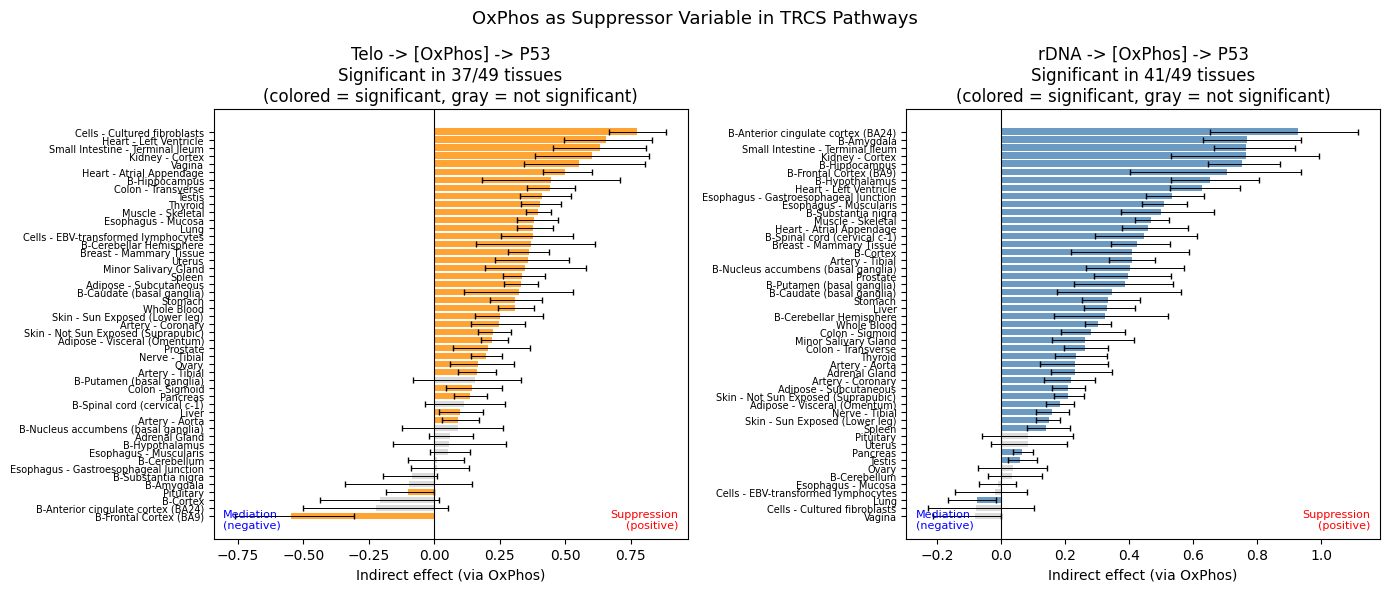

Saved to results/mediation_suppressor.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('OxPhos as Suppressor Variable in TRCS Pathways', fontsize=13)

for ax, pred, color in zip(axes, ['Telo', 'rDNA'], ['darkorange', 'steelblue']):
    sub = med_df[med_df['predictor'] == pred].copy()
    sub = sub.sort_values('indirect')

    # Color bars by significance
    bar_colors = [color if s else 'lightgray' for s in sub['sig_mediation']]

    ax.barh(range(len(sub)), sub['indirect'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    # Add CI error bars
    xerr_lo = sub['indirect'] - sub['ind_CI_lo']
    xerr_hi = sub['ind_CI_hi'] - sub['indirect']
    ax.errorbar(
        sub['indirect'], range(len(sub)),
        xerr=[xerr_lo, xerr_hi],
        fmt='none', color='black', linewidth=0.7, capsize=2
    )

    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [t.replace('Brain - ', 'B-') for t in sub['tissue']],
        fontsize=7
    )
    ax.set_xlabel('Indirect effect (via OxPhos)')
    ax.set_title(f'{pred} -> [OxPhos] -> P53\n'
                 f'Significant in {sub["sig_mediation"].sum()}/{len(sub)} tissues\n'
                 f'(colored = significant, gray = not significant)')

    # Annotate direction
    ax.text(0.98, 0.02, 'Suppression\n(positive)',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color='red')
    ax.text(0.02, 0.02, 'Mediation\n(negative)',
            transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8, color='blue')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mediation_suppressor.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/mediation_suppressor.png")

In [8]:
summary_mediation = """
MEDIATION ANALYSIS SUMMARY
===========================

Question: Does OxPhos decline mediate the relationship between 
TRCS proxies (telomere/rDNA activity) and P53 activation?

Method: Bootstrapped mediation analysis (n=500) via pingouin,
using PC1-residualized scores to isolate pathway-specific variance.
Conducted across 49 tissues with n >= 50 samples.

RESULT 1 - OxPhos acts as a SUPPRESSOR, not a mediator
  Telo -> [OxPhos] -> P53: significant indirect effect in 37/49 tissues
    Positive (suppression): 35 tissues
    Negative (mediation):    2 tissues

  rDNA -> [OxPhos] -> P53: significant indirect effect in 41/49 tissues
    Positive (suppression): 40 tissues
    Negative (mediation):    1 tissue

RESULT 2 - Biological interpretation
  OxPhos and TRCS proxies are positively co-regulated (when one is
  high, the other tends to be high), but have OPPOSITE effects on P53.
  Higher rDNA/Telo activity suppresses P53 (TRCS prediction).
  Lower OxPhos activity activates P53 (mitochondrial senescence).
  Controlling for OxPhos therefore STRENGTHENS the apparent TRCS signal,
  rather than explaining it away.
  
  This indicates parallel, partially independent routes to P53 activation
  rather than a linear causal chain.

RESULT 3 - Two exceptions support genuine mediation in prefrontal cortex
  Brain - Frontal Cortex (BA9) and Brain - Anterior cingulate cortex (BA24)
  show negative indirect effects for the Telo pathway, consistent with
  the known telomere-p53-PGC1a-mitochondria axis in neurons.
  These are highly metabolically demanding, neurodegeneration-vulnerable
  regions where MiDAS signaling may be specifically active.

CONCLUSIONS
  1. Mitochondrial dysfunction and TRCS decline are not in a simple
     causal chain -- they are co-regulated but mechanistically parallel.
  2. The TRCS signal in post-mitotic brain tissue survives OxPhos control,
     lending support to a tissue-specific TRCS mechanism in neurons.
  3. Two follow-up projects are warranted:
     - Project 2: mtDNA copy number as independent mitochondrial proxy
       (breaks transcriptional co-regulation problem)
     - Project 3: MiDAS-specific signature scoring to distinguish genuine
       mitochondrial senescence from metabolic co-regulation,
       particularly in prefrontal cortex regions.
"""

print(summary_mediation)
with open(os.path.join(RESULTS_DIR, 'summary_mediation.txt'), 'w',
          encoding='utf-8') as f:
    f.write(summary_mediation)
print("Saved to results/summary_mediation.txt")


MEDIATION ANALYSIS SUMMARY

Question: Does OxPhos decline mediate the relationship between 
TRCS proxies (telomere/rDNA activity) and P53 activation?

Method: Bootstrapped mediation analysis (n=500) via pingouin,
using PC1-residualized scores to isolate pathway-specific variance.
Conducted across 49 tissues with n >= 50 samples.

RESULT 1 - OxPhos acts as a SUPPRESSOR, not a mediator
  Telo -> [OxPhos] -> P53: significant indirect effect in 37/49 tissues
    Positive (suppression): 35 tissues
    Negative (mediation):    2 tissues

  rDNA -> [OxPhos] -> P53: significant indirect effect in 41/49 tissues
    Positive (suppression): 40 tissues
    Negative (mediation):    1 tissue

RESULT 2 - Biological interpretation
  OxPhos and TRCS proxies are positively co-regulated (when one is
  high, the other tends to be high), but have OPPOSITE effects on P53.
  Higher rDNA/Telo activity suppresses P53 (TRCS prediction).
  Lower OxPhos activity activates P53 (mitochondrial senescence).
  Contro

Saved mediation_results_5000.csv


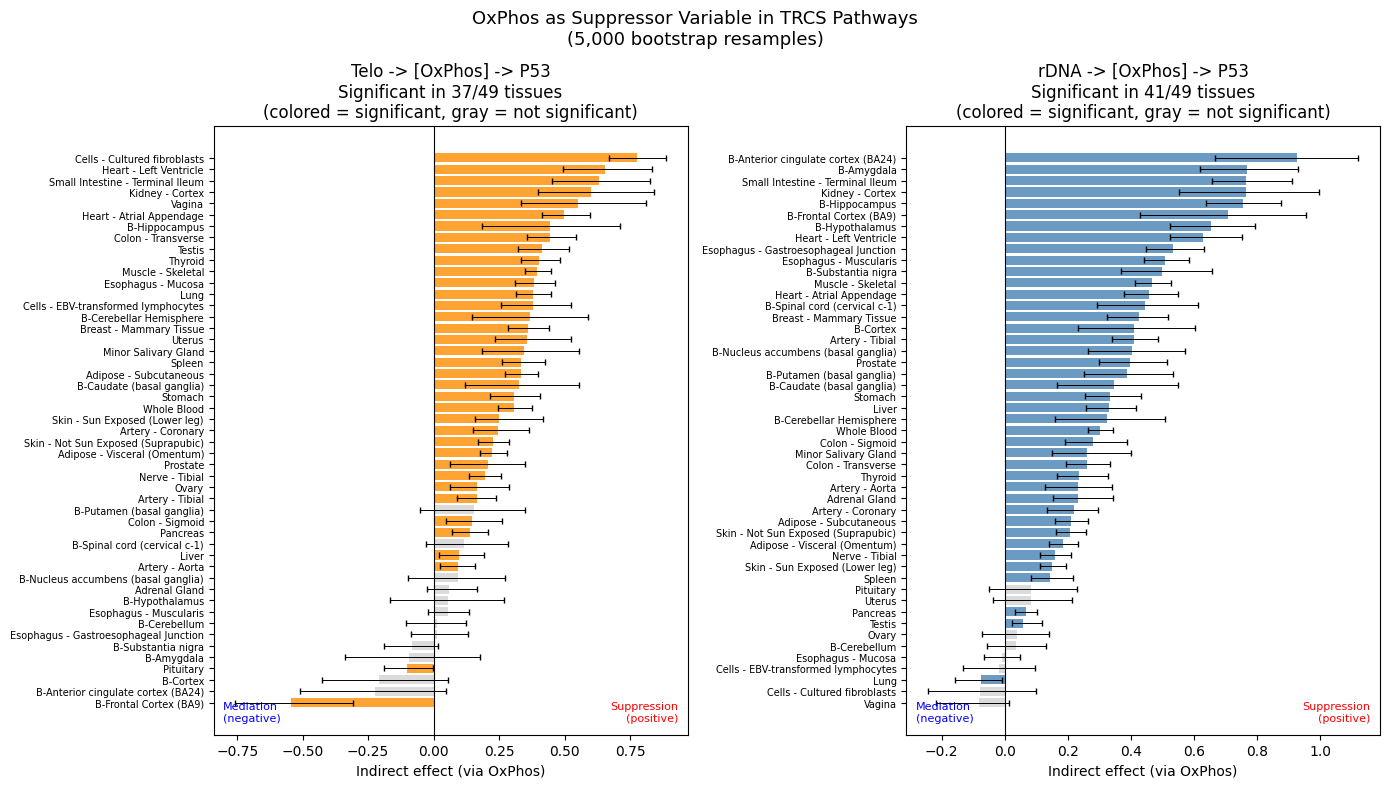

Saved mediation_suppressor_5000.png


In [9]:
# Save updated results
med_df.to_csv(os.path.join(RESULTS_DIR, 'mediation_results_5000.csv'), index=False)
print("Saved mediation_results_5000.csv")

# Regenerate the suppressor figure
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle('OxPhos as Suppressor Variable in TRCS Pathways\n(5,000 bootstrap resamples)', fontsize=13)

for ax, pred, color in zip(axes, ['Telo', 'rDNA'], ['darkorange', 'steelblue']):
    sub = med_df[med_df['predictor'] == pred].copy()
    sub = sub.sort_values('indirect')

    bar_colors = [color if s else 'lightgray' for s in sub['sig_mediation']]

    ax.barh(range(len(sub)), sub['indirect'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    xerr_lo = sub['indirect'] - sub['ind_CI_lo']
    xerr_hi = sub['ind_CI_hi'] - sub['indirect']
    ax.errorbar(
        sub['indirect'], range(len(sub)),
        xerr=[xerr_lo, xerr_hi],
        fmt='none', color='black', linewidth=0.7, capsize=2
    )

    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [t.replace('Brain - ', 'B-') for t in sub['tissue']],
        fontsize=7
    )
    ax.set_xlabel('Indirect effect (via OxPhos)')
    ax.set_title(f'{pred} -> [OxPhos] -> P53\n'
                 f'Significant in {sub["sig_mediation"].sum()}/{len(sub)} tissues\n'
                 f'(colored = significant, gray = not significant)')

    ax.text(0.98, 0.02, 'Suppression\n(positive)',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color='red')
    ax.text(0.02, 0.02, 'Mediation\n(negative)',
            transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8, color='blue')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mediation_suppressor_5000.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved mediation_suppressor_5000.png")